# Benchmark Visualisierung (Week 7)
Hier werten wir die aktuellen Messwerte aus unserer JIT Runtime Umgebung aus.

Führe Benchmarks aus (das kann etwas dauern)...
Benchmarks abgeschlossen! Werte aus...


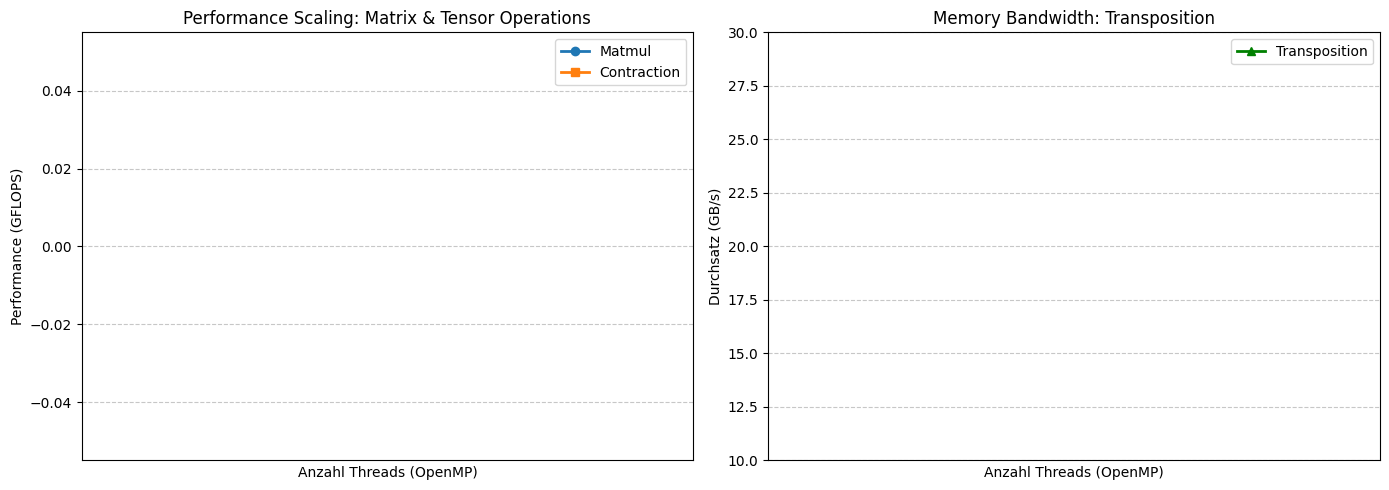

In [ ]:
import subprocess
import re
import matplotlib.pyplot as plt
import numpy as np

print("Führe Benchmarks aus (das kann etwas dauern)...")
# Ausführen der Runtime (im Überordner ../) mit --bench-only
# Wichtig: cwd=".." setzen, damit er die data/*.teir Dateien relativ dazu findet!
result = subprocess.run(["./teir_runtime", "--bench-only"], capture_output=True, text=True, cwd="..")
output = result.stdout

if result.returncode != 0:
    print("Fehler beim Ausführen der Benchmarks:\n", result.stderr)
else:
    print("Benchmarks abgeschlossen! Werte aus...")

# Regex Parsing für GFLOPS und GB/s der jeweiligen Benchmarks
threads_set = set()
matmul_gflops = {}
contraction_gflops = {}
transposition_gbs = {}

for line in output.split('\n'):
    # Pattern für GFLOPS
    match_flops = re.search(r'Benchmark \[(.*?)\] \(threads=(\d+)\):.*\|.*?([0-9.]+) GFLOPS \(best\)', line)
    if match_flops:
        name = match_flops.group(1)
        t = int(match_flops.group(2))
        val = float(match_flops.group(3))
        threads_set.add(t)
        if name == 'matmul':
            matmul_gflops[t] = val
        elif name == 'contraction':
            contraction_gflops[t] = val
            
    # Pattern für GB/s
    match_gbs = re.search(r'Benchmark \[(.*?)\] \(threads=(\d+)\):.*\|.*?([0-9.]+) GB/s \(best\)', line)
    if match_gbs:
        name = match_gbs.group(1)
        t = int(match_gbs.group(2))
        val = float(match_gbs.group(3))
        threads_set.add(t)
        if name == 'transposition':
            transposition_gbs[t] = val

threads = sorted(list(threads_set))
matmul_vals = [matmul_gflops.get(t, 0) for t in threads]
contraction_vals = [contraction_gflops.get(t, 0) for t in threads]
transposition_vals = [transposition_gbs.get(t, 0) for t in threads]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: GFLOPS (Matmul & Contraction)
ax1.plot(threads, matmul_vals, marker='o', linestyle='-', linewidth=2, label='Matmul')
ax1.plot(threads, contraction_vals, marker='s', linestyle='-', linewidth=2, label='Contraction')
ax1.set_title('Performance Scaling: Matrix & Tensor Operations')
ax1.set_xlabel('Anzahl Threads (OpenMP)')
ax1.set_ylabel('Performance (GFLOPS)')
ax1.set_xticks(threads)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

if threads and len(contraction_vals) > 0:
    ax1.text(threads[-1], contraction_vals[-1] + 20, f'{contraction_vals[-1]:.1f} GFLOPS', ha='center', va='bottom', fontsize=9)
if threads and len(matmul_vals) > 0:
    ax1.text(threads[-1], matmul_vals[-1] - 30, f'{matmul_vals[-1]:.1f} GFLOPS', ha='center', va='top', fontsize=9)

# Graph 2: GB/s (Transposition)
ax2.plot(threads, transposition_vals, marker='^', linestyle='-', linewidth=2, color='green', label='Transposition')
ax2.set_title('Memory Bandwidth: Transposition')
ax2.set_xlabel('Anzahl Threads (OpenMP)')
ax2.set_ylabel('Durchsatz (GB/s)')
ax2.set_xticks(threads)
ax2.set_ylim(10, 30)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.savefig('benchmark_graphs.png', dpi=300)
plt.show()